# Histogram Equalization for Image Contrast Enhancement
## Using Uniform Distribution Transformation

This notebook implements histogram equalization to enhance image contrast by redistributing pixel intensities across the full dynamic range.

---

## Mathematical Foundation: The (L-1) × Σ(nk/NM) Formula

The histogram equalization transformation is:

$$s_k = (L-1) \times \sum_{j=0}^{k} \frac{n_j}{M \times N}$$

Breaking down each component:

1. **$n_j$** = Number of pixels with intensity level $j$
   - This is the count from the histogram

2. **$M \times N$** = Total number of pixels in the image
   - $M$ = image height (rows)
   - $N$ = image width (columns)

3. **$\frac{n_j}{M \times N}$** = Probability of intensity level $j$
   - This is $p(r_j)$, the normalized histogram
   - Represents what fraction of pixels have intensity $j$

4. **$\sum_{j=0}^{k}$** = Cumulative sum from 0 to $k$
   - This gives us the CDF (Cumulative Distribution Function)
   - $CDF(k)$ = probability that a pixel has intensity $\leq k$

5. **$L-1$** = Maximum intensity value
   - For 8-bit images: $L = 256$, so $L-1 = 255$
   - This scales the CDF to the full intensity range

### Why This Works:

- The CDF tells us what fraction of pixels are $\leq$ intensity $k$
- Multiplying by $(L-1)$ scales this to the output range $[0, 255]$
- Dark images have CDF values concentrated near 0
- This transformation spreads them across the full range
- **Result**: Enhanced contrast with approximately uniform distribution

### Example Calculation:

Suppose we have a $100 \times 100$ pixel image (10,000 total pixels)

At intensity level $k=50$:
- $n_{50} = 200$ pixels have intensity 50
- $\sum_{j=0}^{50} n_j = 3000$ pixels have intensity $\leq 50$

Then:
$$s_{50} = 255 \times \frac{3000}{10000} = 255 \times 0.3 = 76.5 \approx 77$$

So all pixels with original intensity 50 → new intensity 77

---

## Import Required Libraries

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Set up matplotlib for inline plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 10)

## Step 1: Histogram Equalization Function

In [23]:
def histogram_equalization(image):
    print(type(image))
    """
    Perform histogram equalization on a grayscale image.

    Parameters:
    -----------
    image : numpy array
        Input grayscale image (2D array)

    Returns:
    --------
    equalized_image : numpy array
        Histogram equalized image
    histogram_original : numpy array
        Histogram of original image
    histogram_equalized : numpy array
        Histogram of equalized image
    transformation_function : numpy array
        The transformation function s = T(r)
    """

    # Get image dimensions
    M, N = image.shape  # M = height, N = width
    total_pixels = M * N

    # Number of intensity levels (for 8-bit image, L = 256)
    L = 256

    # Step 0: Calculate histogram (frequency of each intensity level)
    histogram_original, _ = np.histogram(image.flatten(), bins=L, range=(0, L))

    print("="*70)
    print("HISTOGRAM EQUALIZATION")
    print("="*70)
    print(f"\nImage dimensions: {M} × {N} = {total_pixels} total pixels")
    print(f"Intensity levels (L): {L} (range 0 to {L-1})")

    # Step 1: Calculate probability density function (PDF)
    # p(rk) = nk / (M*N)
    # where nk is the number of pixels with intensity k
    pdf = histogram_original / total_pixels

    print("\n" + "-"*70)
    print("STEP 1: Calculate Probability Density Function (PDF)")
    print("-"*70)
    print("Formula: p(rk) = nk / (M×N)")
    print("where nk = number of pixels with intensity level k")

    # Step 2: Calculate Cumulative Distribution Function (CDF)
    # This is the transformation function: s = T(r)
    # sk = (L-1) * Σ(j=0 to k) p(rj)
    # sk = (L-1) * Σ(j=0 to k) nj/(M*N)

    cdf = np.cumsum(pdf)  # Cumulative sum of probabilities

    print("\n" + "-"*70)
    print("STEP 2: Calculate Cumulative Distribution Function (CDF)")
    print("-"*70)
    print("Formula: CDF(k) = Σ(j=0 to k) p(rj)")
    print("\nThis represents the cumulative probability up to intensity k")

    # Step 4: Apply the transformation function
    # sk = (L-1) × CDF(k)
    # This is where the (L-1) × Σ(nk/NM) formula is applied!

    transformation_function = (L - 1) * cdf

    print("\n" + "-"*70)
    print("STEP 3: Apply Transformation Function")
    print("-"*70)
    print("Formula: sk = (L-1) × CDF(k)")
    print("        sk = (L-1) × Σ(j=0 to k) [nj/(M×N)]")
    print(f"\nWhere L-1 = {L-1} (maximum intensity value)")
    print("\nThis formula maps input intensity rk to output intensity sk")

    # Step 5: Map the original image intensities to new values
    equalized_image = np.interp(image.flatten(), range(L), transformation_function)
    # Plot the results using Matplotlib
    plt.figure(figsize=(8, 6))
    # Plot the interpolated values as a line
    plt.scatter(image.flatten(), equalized_image, label='Linear Interpolation')

    plt.xlabel('rk')
    plt.ylabel('sk')
    plt.title('Equalization transformation')
    plt.legend()
    plt.grid(True)
    plt.show()

    equalized_image = equalized_image.reshape(image.shape).astype(np.uint8)

    print("\n" + "-"*70)
    print("STEP 4: Apply Transformation to Image")
    print("-"*70)
    print("Each pixel intensity is mapped using the transformation function")

    # Calculate histogram of equalized image
    histogram_equalized, _ = np.histogram(equalized_image.flatten(), bins=L, range=(0, L))

    return equalized_image, histogram_original, histogram_equalized, transformation_function

## Step 2: Visualization Function

In [24]:
def visualize_results(original, equalized, hist_orig, hist_eq, transform_func):
    """
    Create comprehensive visualization of the histogram equalization process
    """
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    # Original image
    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')

    # Equalized image
    axes[0, 1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title('Histogram Equalized Image', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')

    # Original histogram
    axes[1, 0].bar(range(256), hist_orig, color='blue', alpha=0.7, width=1)
    axes[1, 0].set_title('Original Histogram', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Intensity Level (r)', fontsize=10)
    axes[1, 0].set_ylabel('Frequency (nk)', fontsize=10)
    axes[1, 0].set_xlim([0, 255])
    axes[1, 0].grid(True, alpha=0.3)

    # Equalized histogram
    axes[1, 1].bar(range(256), hist_eq, color='green', alpha=0.7, width=1)
    axes[1, 1].set_title('Equalized Histogram', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Intensity Level (s)', fontsize=10)
    axes[1, 1].set_ylabel('Frequency', fontsize=10)
    axes[1, 1].set_xlim([0, 255])
    axes[1, 1].grid(True, alpha=0.3)

    # Transformation function
    axes[2, 0].plot(range(256), transform_func, 'r-', linewidth=2)
    axes[2, 0].plot([0, 255], [0, 255], 'k--', alpha=0.3, label='Identity (no change)')
    axes[2, 0].set_title('Transformation Function: sk = (L-1)×CDF(rk)',
                         fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Input Intensity (rk)', fontsize=10)
    axes[2, 0].set_ylabel('Output Intensity (sk)', fontsize=10)
    axes[2, 0].set_xlim([0, 255])
    axes[2, 0].set_ylim([0, 255])
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()

    # CDF comparison
    cdf_orig = np.cumsum(hist_orig) / np.sum(hist_orig)
    cdf_eq = np.cumsum(hist_eq) / np.sum(hist_eq)

    axes[2, 1].plot(range(256), cdf_orig, 'b-', linewidth=2, label='Original CDF')
    axes[2, 1].plot(range(256), cdf_eq, 'g-', linewidth=2, label='Equalized CDF')
    axes[2, 1].plot([0, 255], [0, 1], 'k--', alpha=0.3, label='Ideal uniform CDF')
    axes[2, 1].set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
    axes[2, 1].set_xlabel('Intensity Level', fontsize=10)
    axes[2, 1].set_ylabel('CDF = Σ(nj/NM)', fontsize=10)
    axes[2, 1].set_xlim([0, 255])
    axes[2, 1].set_ylim([0, 1])
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend()

    plt.tight_layout()
    plt.show()

## Step 3: Read image or create a sample image

Let's read the image or create a low-contrast synthetic image for demonstration purposes.

Sample low-contrast image created successfully!
Image shape: (400, 400)
Data type: uint8


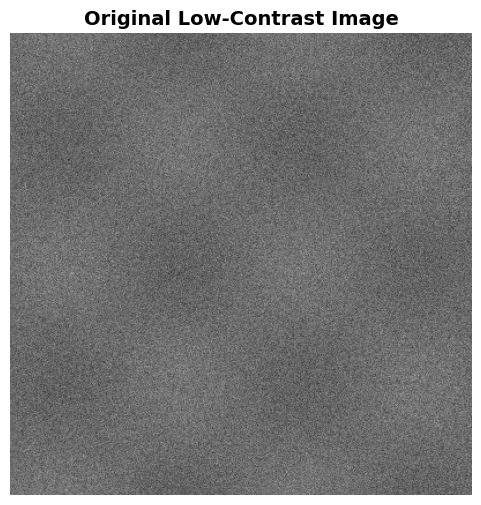

In [25]:
# Create a sample low-contrast image for demonstration
np.random.seed(42)

# Create a synthetic low-contrast image
image = np.random.normal(100, 20, (400, 400))
image = np.clip(image, 0, 255).astype(np.uint8)

# Add some structure (sinusoidal pattern)
x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
pattern = 128 + 30 * np.sin(3*x) * np.cos(3*y)
image = (0.7 * image + 0.3 * pattern).astype(np.uint8)

print("Sample low-contrast image created successfully!")
print(f"Image shape: {image.shape}")
print(f"Data type: {image.dtype}")

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Low-Contrast Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

## Step 4: Apply Histogram Equalization

Now let's apply the histogram equalization transformation using the formula:

$$s_k = (L-1) \times \sum_{j=0}^{k} \frac{n_j}{M \times N}$$

<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 400 × 400 = 160000 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

----------------------------------------------------------------------
STEP 3: Apply Transformation Function
----------------------------------------------------------------------
Formula: sk = (L-1) × CDF(k)
        sk = (L-1) × Σ(j=0 to k) [nj/(M×N)]

Where L-1 = 255 (maximum intens

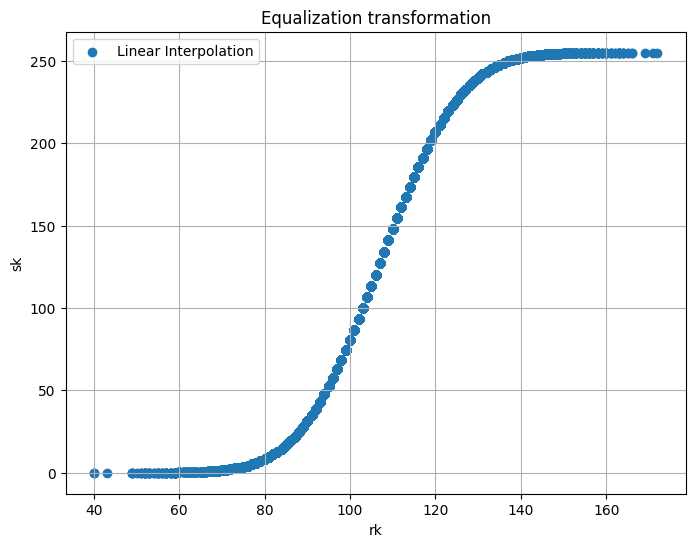


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function


In [26]:
# Perform histogram equalization
equalized, hist_orig, hist_eq, transform_func = histogram_equalization(image)

## Step 5: Visualize Results

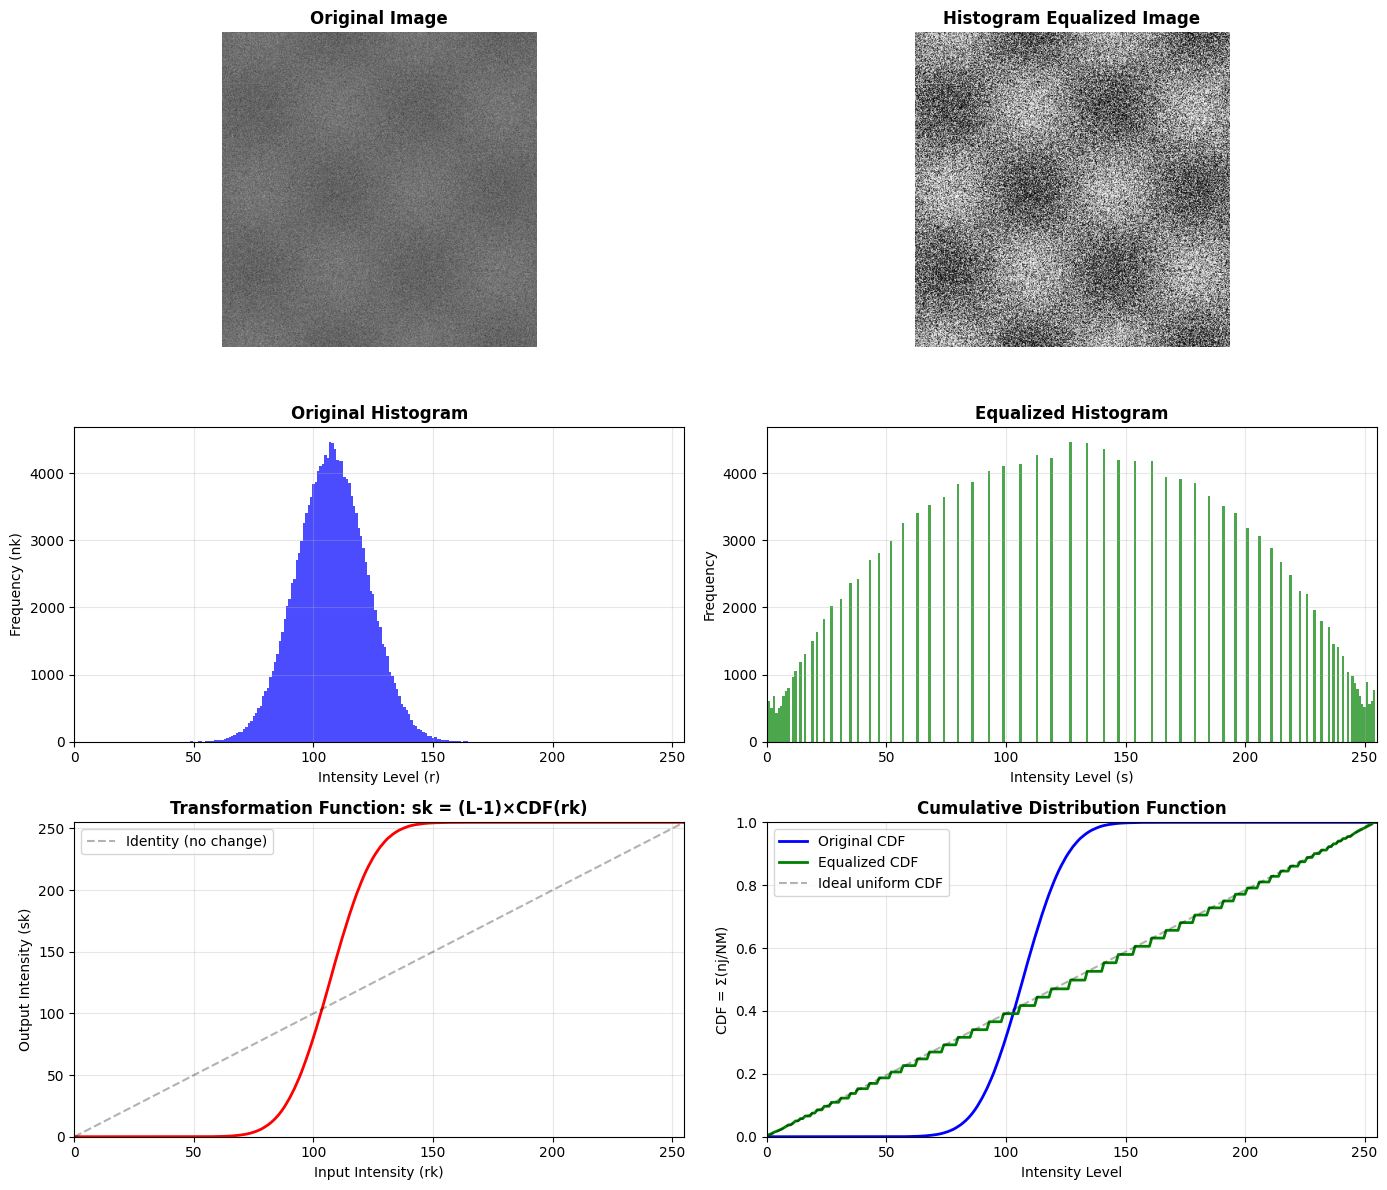

In [27]:
# Visualize the complete results
visualize_results(image, equalized, hist_orig, hist_eq, transform_func)

## Step 6: Calculate Statistics

In [28]:
print("="*70)
print("RESULTS SUMMARY")
print("="*70)

print(f"\nOriginal Image Statistics:")
print(f"  Mean intensity: {np.mean(image):.2f}")
print(f"  Std deviation: {np.std(image):.2f}")
print(f"  Min intensity: {np.min(image)}")
print(f"  Max intensity: {np.max(image)}")
print(f"  Intensity range: {np.max(image) - np.min(image)}")

print(f"\nEqualized Image Statistics:")
print(f"  Mean intensity: {np.mean(equalized):.2f}")
print(f"  Std deviation: {np.std(equalized):.2f}")
print(f"  Min intensity: {np.min(equalized)}")
print(f"  Max intensity: {np.max(equalized)}")
print(f"  Intensity range: {np.max(equalized) - np.min(equalized)}")

print(f"\nContrast Enhancement:")
original_range = np.max(image) - np.min(image)
equalized_range = np.max(equalized) - np.min(equalized)
print(f"  Original range: {original_range}")
print(f"  Equalized range: {equalized_range}")
print(f"  Range increase: {((equalized_range - original_range) / original_range * 100):.1f}%")

print("\n" + "="*70)
print("Key Takeaways:")
print("="*70)
print("• Histogram equalization redistributes pixel intensities")
print("• The formula sk = (L-1)×Σ(nk/NM) maps input to output intensities")
print("• Result: Better contrast and more uniform intensity distribution")
print("• Works best on images with poor contrast or limited dynamic range")
print("="*70)

RESULTS SUMMARY

Original Image Statistics:
  Mean intensity: 107.57
  Std deviation: 14.70
  Min intensity: 40
  Max intensity: 172
  Intensity range: 132

Equalized Image Statistics:
  Mean intensity: 129.46
  Std deviation: 73.61
  Min intensity: 0
  Max intensity: 255
  Intensity range: 255

Contrast Enhancement:
  Original range: 132
  Equalized range: 255
  Range increase: 93.2%

Key Takeaways:
• Histogram equalization redistributes pixel intensities
• The formula sk = (L-1)×Σ(nk/NM) maps input to output intensities
• Result: Better contrast and more uniform intensity distribution
• Works best on images with poor contrast or limited dynamic range


## Step 7: Apply to Your Own Image

You can load and process your own grayscale image:

<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 342 × 345 = 117990 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

----------------------------------------------------------------------
STEP 3: Apply Transformation Function
----------------------------------------------------------------------
Formula: sk = (L-1) × CDF(k)
        sk = (L-1) × Σ(j=0 to k) [nj/(M×N)]

Where L-1 = 255 (maximum intens

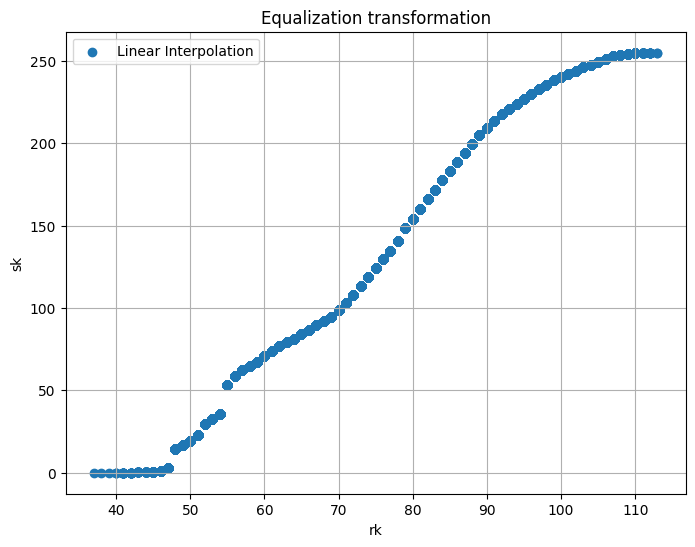


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function


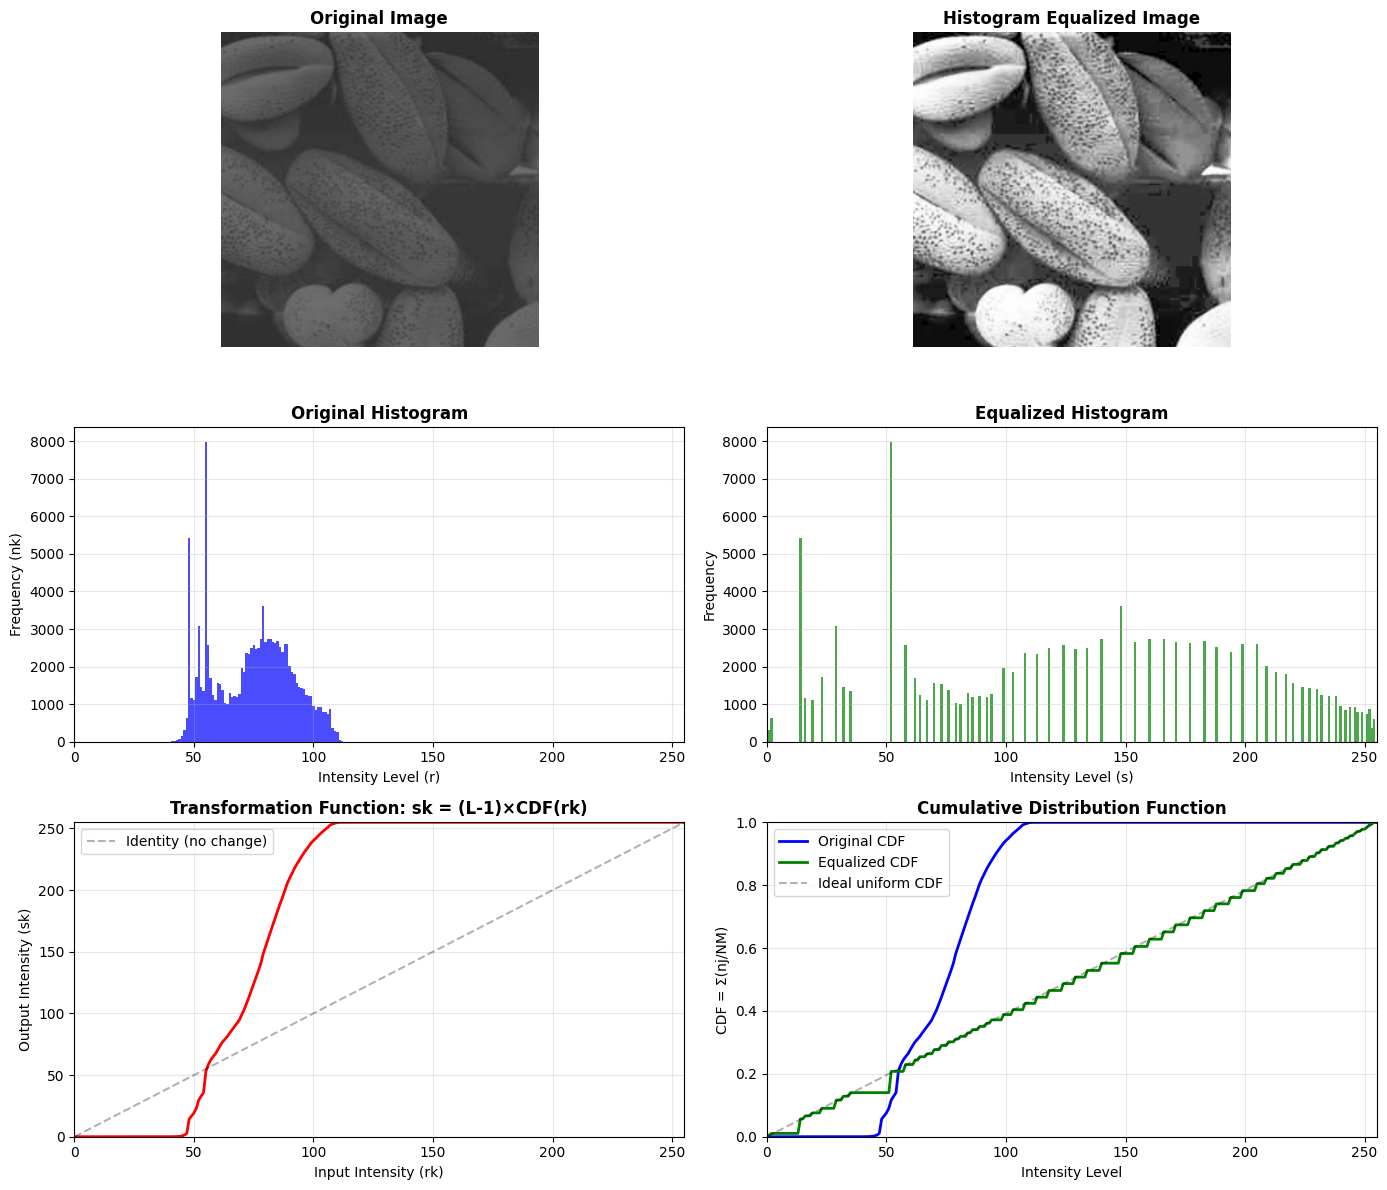

In [29]:
from PIL import Image
import os

subfolder_name = "Test images"
file_name = "img.png"
pathname = os.path.join(subfolder_name,file_name)

# Load your image
img = Image.open(pathname).convert('L')  # Convert to grayscale
image = np.array(img)

# Apply histogram equalization
equalized, hist_orig, hist_eq, transform_func = histogram_equalization(image)

# Visualize
visualize_results(image, equalized, hist_orig, hist_eq, transform_func)
# Save the result
result_img = Image.fromarray(equalized)


## Section 8: Batch Equalization of All Images in 'Test images' Folder

This section loads every image from the **`Test images`** folder, applies histogram equalization to each one, and displays them in a grid with two columns:
- **Left column** → Original image
- **Right column** → Equalized image

Found 7 image(s) in 'Test images':
  • img.png
  • img1.jfif
  • img2.jpg
  • img3.png
  • img4.png
  • img5.png
  • img6.jpg
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 342 × 345 = 117990 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

----------------------------------------------------------------------
STEP 3: Apply Transformation Function
--------------------------------------------------

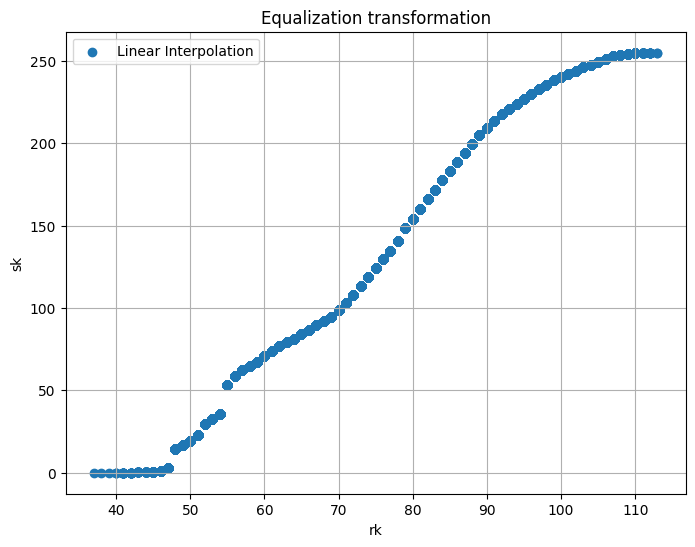


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 225 × 225 = 50625 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

----------------------------------------

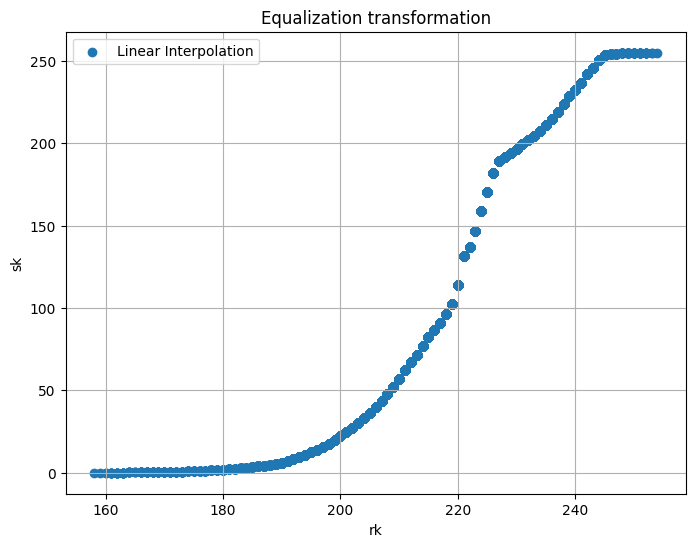


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 405 × 402 = 162810 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

---------------------------------------

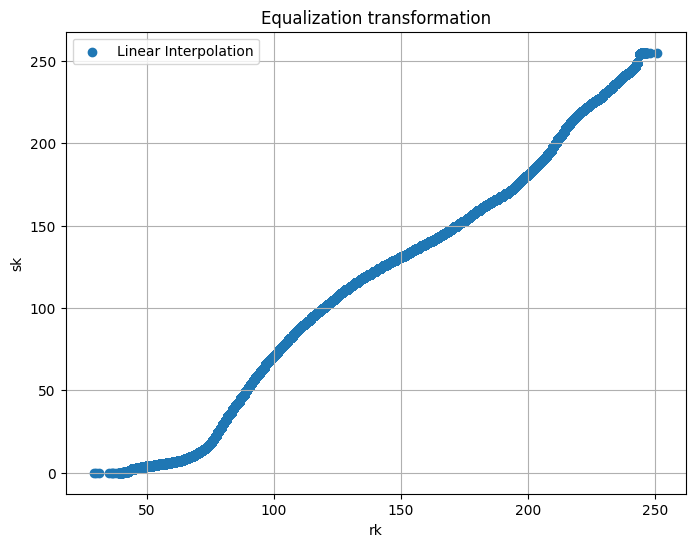


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 340 × 344 = 116960 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

---------------------------------------

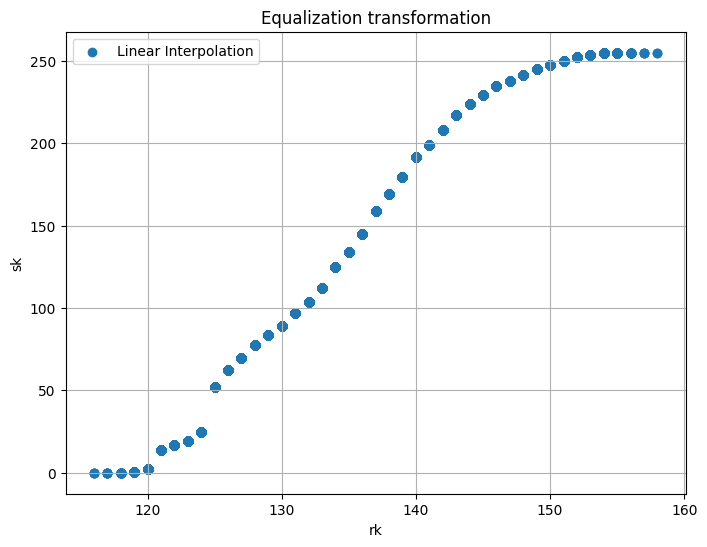


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 347 × 344 = 119368 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

---------------------------------------

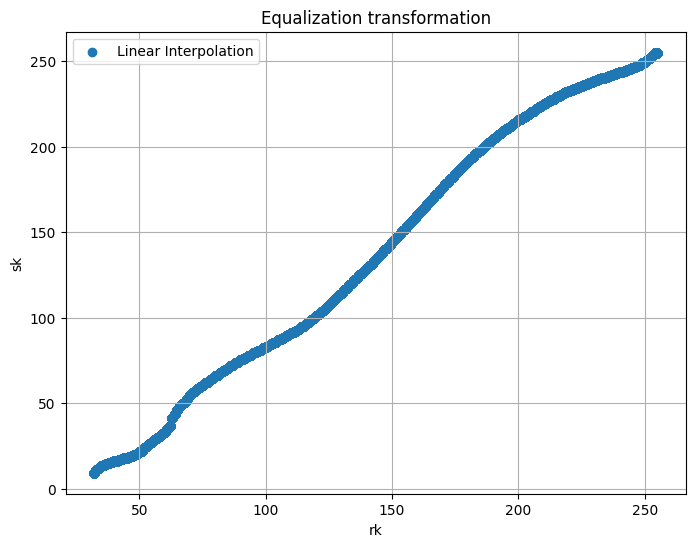


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 288 × 233 = 67104 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

----------------------------------------

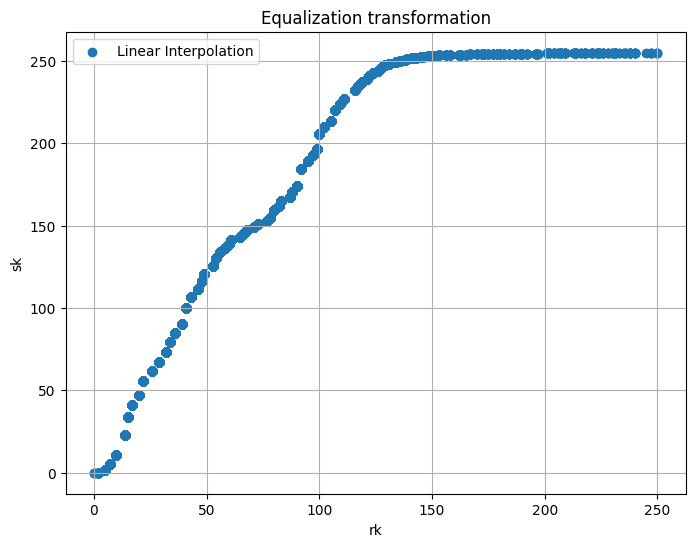


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function
<class 'numpy.ndarray'>
HISTOGRAM EQUALIZATION

Image dimensions: 182 × 165 = 30030 total pixels
Intensity levels (L): 256 (range 0 to 255)

----------------------------------------------------------------------
STEP 1: Calculate Probability Density Function (PDF)
----------------------------------------------------------------------
Formula: p(rk) = nk / (M×N)
where nk = number of pixels with intensity level k

----------------------------------------------------------------------
STEP 2: Calculate Cumulative Distribution Function (CDF)
----------------------------------------------------------------------
Formula: CDF(k) = Σ(j=0 to k) p(rj)

This represents the cumulative probability up to intensity k

----------------------------------------

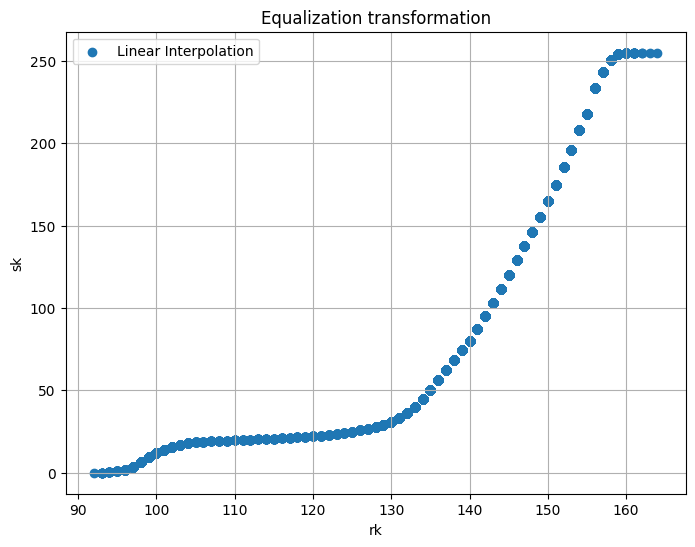


----------------------------------------------------------------------
STEP 4: Apply Transformation to Image
----------------------------------------------------------------------
Each pixel intensity is mapped using the transformation function


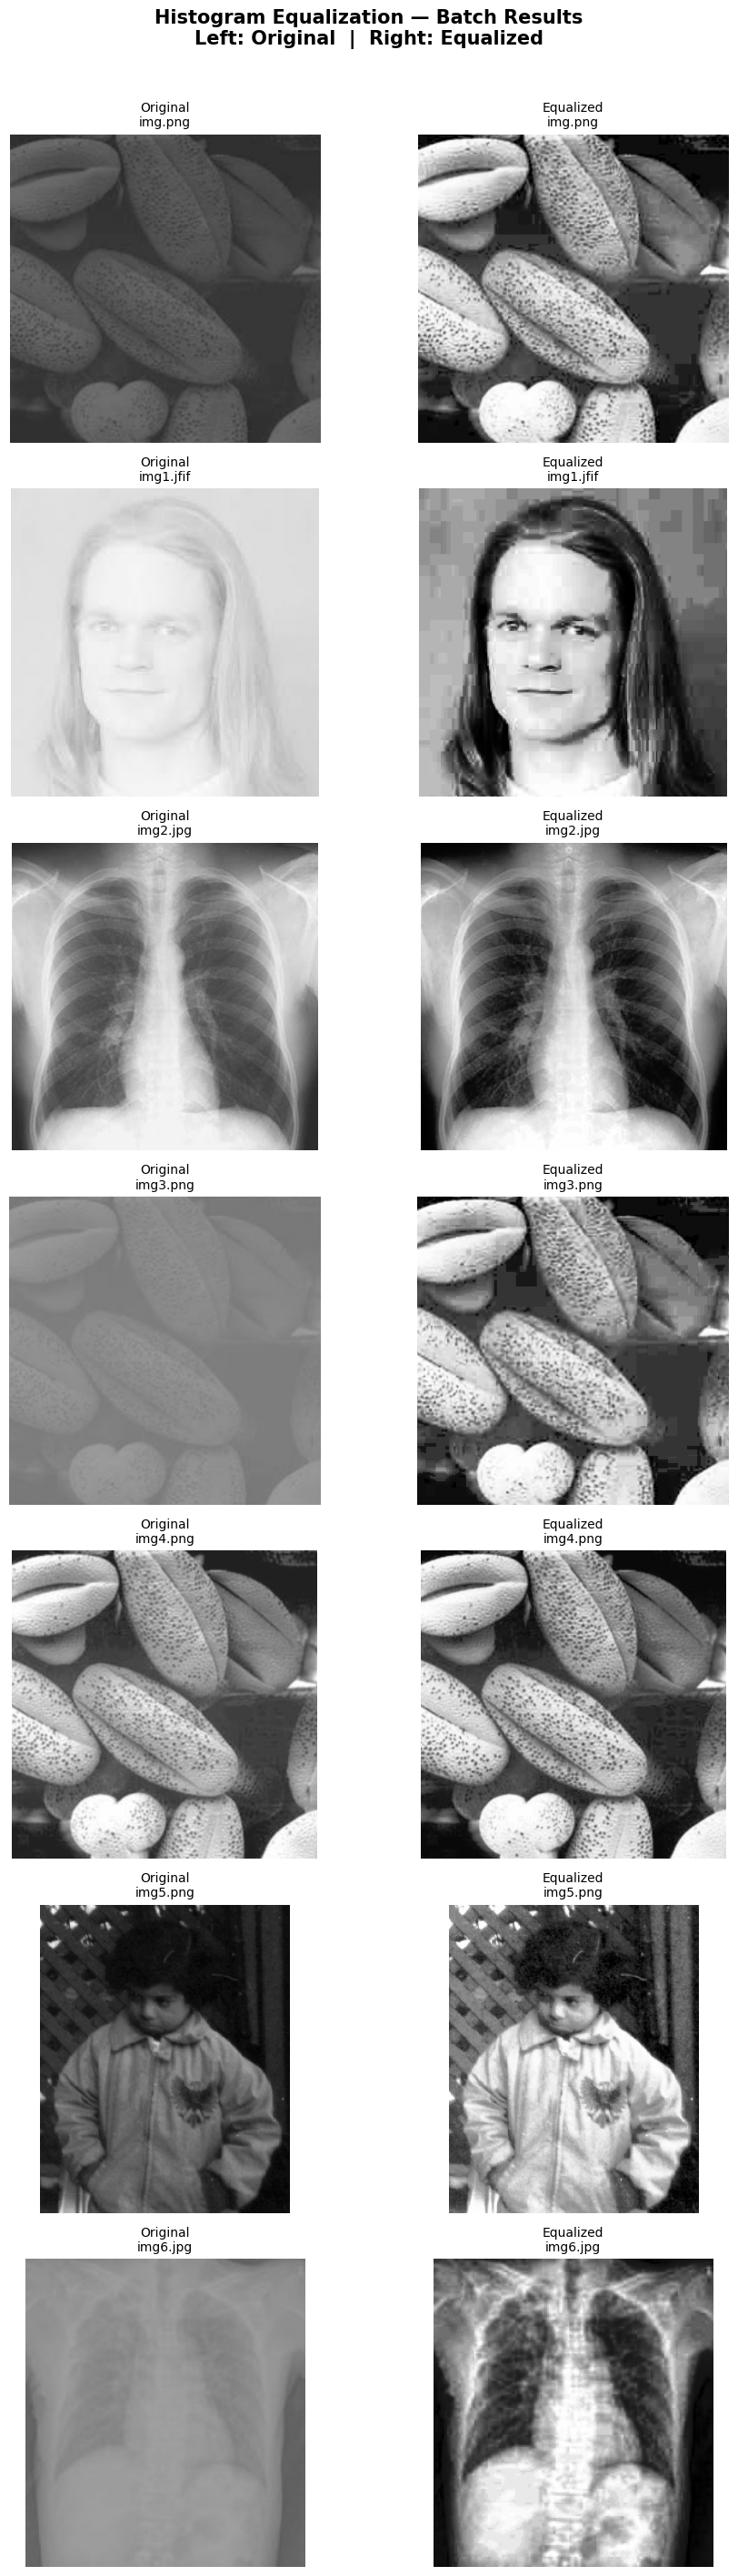

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── Configuration ──────────────────────────────────────────────────────────
TEST_IMAGES_FOLDER = 'Test images'          # Folder containing the test images
SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.jfif', '.png', '.bmp', '.tif', '.tiff')

# ── Collect image paths ────────────────────────────────────────────────────
image_paths = sorted([
    os.path.join(TEST_IMAGES_FOLDER, f)
    for f in os.listdir(TEST_IMAGES_FOLDER)
    if f.lower().endswith(SUPPORTED_EXTENSIONS)
])

if not image_paths:
    raise FileNotFoundError(
        f"No supported images found in '{TEST_IMAGES_FOLDER}'. "
        f"Supported formats: {SUPPORTED_EXTENSIONS}"
    )

print(f"Found {len(image_paths)} image(s) in '{TEST_IMAGES_FOLDER}':")
for p in image_paths:
    print(f"  • {os.path.basename(p)}")

# ── Load & equalize each image ─────────────────────────────────────────────
originals  = []
equalizeds = []
filenames  = []

for path in image_paths:
    img_pil  = Image.open(path).convert('L')   # Convert to grayscale
    img_arr  = np.array(img_pil)
    eq_arr, _, _, _ = histogram_equalization(img_arr)
    originals.append(img_arr)
    equalizeds.append(eq_arr)
    filenames.append(os.path.basename(path))

# ── Build the comparison grid ──────────────────────────────────────────────
n          = len(originals)
row_height = 4                              # inches per row
fig, axes  = plt.subplots(
    nrows=n, ncols=2,
    figsize=(10, row_height * n),
    squeeze=False
)

fig.suptitle(
    'Histogram Equalization — Batch Results\n'
    'Left: Original  |  Right: Equalized',
    fontsize=15, fontweight='bold', y=1.01
)

for i, (orig, eq, fname) in enumerate(zip(originals, equalizeds, filenames)):
    # ── Left column: original ──────────────────────────────────────────
    axes[i, 0].imshow(orig, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Original\n{fname}', fontsize=10)
    axes[i, 0].axis('off')

    # ── Right column: equalized ────────────────────────────────────────
    axes[i, 1].imshow(eq, cmap='gray', vmin=0, vmax=255)
    axes[i, 1].set_title(f'Equalized\n{fname}', fontsize=10)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Mathematical Derivation Summary

### Original Intensity Distribution:
- Let $r$ represent input intensity levels: $r \in [0, L-1]$
- Probability density function: $p_r(r_k) = \frac{n_k}{M \times N}$

### Transformation Function:
- We want to transform $r$ to $s$ such that $s$ has a uniform distribution
- The transformation is based on the CDF: $s = T(r) = (L-1) \int_0^r p_r(w) dw$
- For discrete case: $s_k = (L-1) \sum_{j=0}^{k} p_r(r_j) = (L-1) \sum_{j=0}^{k} \frac{n_j}{M \times N}$

### Properties:
1. **Monotonic**: If $r_1 < r_2$, then $s_1 < s_2$
2. **Range preserving**: $0 \leq s \leq L-1$
3. **Approximately uniform**: Output histogram tends toward uniform distribution

---

## References
- Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th ed.). Pearson.
- Pratt, W. K. (2007). Digital Image Processing (4th ed.). Wiley-Interscience.